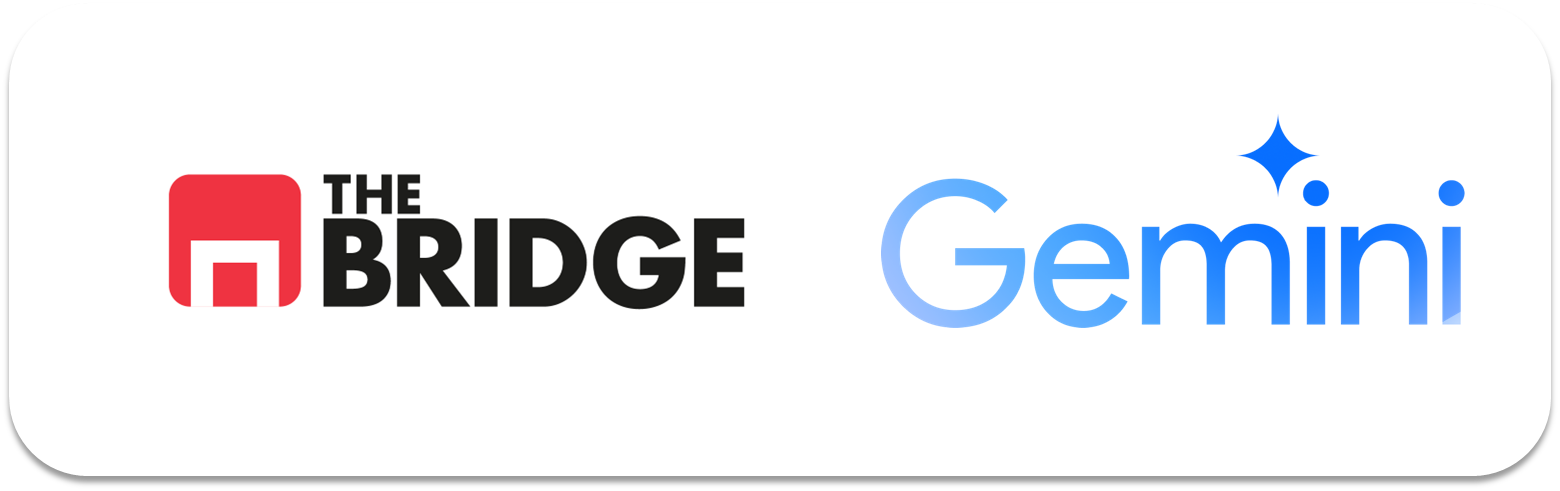

# De prompt suelto a asistente (Assistant Engineering)

**Idea:** comparar una **llamada directa** a Gemini con un **asistente mínimo** que guarda estado entre turnos.

**Prerrequisitos:** clave de Google AI Studio. Usa `GEMINI_API_KEY` o `getpass` en setup.

## 0) Instalación y cliente

In [ ]:
%pip install -q -U google-genai

import os
import getpass

from google import genai

if not os.getenv("GEMINI_API_KEY"):
    os.environ["GEMINI_API_KEY"] = getpass.getpass(
        "Pega aquí tu GEMINI_API_KEY (input oculto): "
    )

print("GEMINI_API_KEY configurada:", "sí" if os.getenv("GEMINI_API_KEY") else "no")

MODEL = "gemini-3-flash-preview"
client = genai.Client()


def llamar_gemini(prompt: str, max_chars: int = 900) -> str:
    r = client.models.generate_content(model=MODEL, contents=prompt)
    texto = (r.text or "").strip()
    if len(texto) > max_chars:
        return texto[:max_chars] + "\n... [truncado]"
    return texto


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
GEMINI_API_KEY configurada: sí


## 1) Prompt suelto — dos llamadas independientes

Cada `generate_content` es **aislada**. No hay memoria entre celdas salvo lo que tú reenvíes en el texto.

Turno 1: el usuario se presenta. 
Turno 2: pregunta por su nombre **sin** repetir el turno 1 en el prompt.

In [ ]:
TURNO_1 = "Me llamo Ana y estudio Assistant Engineering en el bootcamp."
TURNO_2 = "¿Cómo me llamo y qué estoy estudiando?"

print("=== Turno 1 (prompt suelto) ===")
print(llamar_gemini(TURNO_1))

print("\n=== Turno 2 (prompt suelto, sin historial) ===")
print(llamar_gemini(TURNO_2))

=== Turno 1 (prompt suelto) ===
¡Hola Ana! ¡Un placer conocerte!

Qué interesante que estés estudiando Assistant Engineering en un bootcamp. Es un campo con muchísimo futuro y muy demandado hoy en día, especialmente con el crecimiento de la IA y la necesidad de optimizar procesos y dar soporte a los equipos de ingeniería.

¡Seguro que estás aprendiendo un montón y adquiriendo habilidades muy valiosas!

¿Qué es lo que más te está gustando o qué tipo de proyectos te emocionan más en este campo? ¡Mucha suerte con tus estudios!


**Qué observar:** en el turno 2 el modelo **no tiene** el turno 1 a menos que lo copies en el prompt. Eso limita cualquier “chat” real.

## 2) Asistente mínimo — estado + prompt por turno

Misma API, pero Python **guarda** perfil e historial y los **inyecta** en cada llamada.

In [ ]:
def crear_estado() -> dict:
    return {"user_profile": {}, "messages": []}


def actualizar_perfil(state: dict, mensaje: str) -> None:
    msg = mensaje.lower()
    
    PALABRAS_EXCLUIDAS = {"y", "que", "el", "la", "un", "una", "cómo", "como"}
    
    if "me llamo" in msg:
        resto = msg.split("me llamo", 1)[-1].strip().strip(".")
        if resto:
            nombre = resto.split()[0].capitalize()
            if nombre.lower() not in PALABRAS_EXCLUIDAS:
                state["user_profile"]["nombre"] = nombre

    if "estudio" in msg or "estudiando" in msg:
        if "assistant engineering" in msg:
            state["user_profile"]["tema"] = "Assistant Engineering"


def build_turn_prompt(state: dict, user_message: str) -> str:
    profile = state.get("user_profile", {})
    historial = "\n".join(
        f"{m['role']}: {m['text']}" for m in state.get("messages", [])
    ) or "(sin historial)"
    return f"""
Eres un tutor de estudio. Usa el perfil y el historial si existen.

Perfil conocido:
- Nombre: {profile.get('nombre', '(desconocido)')}
- Tema: {profile.get('tema', '(desconocido)')}

Historial:
{historial}

Mensaje actual:
{user_message.strip()}
""".strip()


def procesar_turno(state: dict, user_message: str) -> str:
    prompt = build_turn_prompt(state, user_message)
    respuesta = llamar_gemini(prompt)
    actualizar_perfil(state, user_message)
    state["messages"].append({"role": "user", "text": user_message})
    state["messages"].append({"role": "assistant", "text": respuesta})
    return respuesta

In [6]:
state = crear_estado()

for msg in (TURNO_1, TURNO_2):
    print("\n" + "=" * 50)
    print(f"Usuario: {msg}")
    print("=" * 50)
    print(procesar_turno(state, msg))

print("\nEstado final (perfil):", state["user_profile"])


Usuario: Me llamo Ana y estudio Assistant Engineering en el bootcamp.
¡Hola, Ana! ¡Es un placer conocerte!

¡Qué interesante que estés estudiando Assistant Engineering en el bootcamp! Suena a un campo muy dinámico y con muchas oportunidades. Los bootcamps son intensos, pero también increíblemente efectivos para adquirir habilidades rápidamente.

Como tu tutor de estudio, estoy aquí para apoyarte en todo lo que necesites. Ya sea organizando tu material, aclarando dudas sobre temas específicos, preparando proyectos o simplemente charlando sobre estrategias de estudio para mantener el ritmo intenso del bootcamp.

Para empezar, me encantaría saber un poco más:

*   ¿Hay algún tema o área específica dentro de Assistant Engineering en la que sientas que necesitas más apoyo o que te genere más curiosidad?
*   ¿Cómo te sientes con el ritmo del bootcamp hasta ahora?
*   ¿Hay algo en particular con lo que te gustaría que te ayude hoy mismo?

Estoy aquí para hacer es
... [truncado]

Usuario: ¿Có

## 3) Para reflexionar

- ¿Qué cambió entre el enfoque suelto y el asistente mínimo?
- ¿Qué piezas pasarías a `config.py`, `state.py`, `prompts.py` y `logic.py` en un proyecto real?